# Experiment 1
***

A classification model to differentiate between cardiac and abdominal ultrasounds
***

This experiment evaluates whether traditional machine learning models can differentiate between cardiac and abdominal ultrasound images. The task is relatively straightforward, as the two classes represent anatomically distinct regions with clearly different visual characteristics.

Both k-Nearest Neighbours (kNN) and Support Vector Machine (SVM) achieved perfect classification performance, with accuracy, precision, recall and F1-score all equal to 1.00. This indicates that the models were able to completely separate the two classes. The results suggest that the visual differences between cardiac and abdominal ultrasound images are sufficiently pronounced for even simple classifiers to detect, despite the inherent noise and low contrast associated with ultrasound data.

In addition, both models exhibited very similar runtime performance (kNN: 0.1766s, SVM: 0.1794s), indicating that computational efficiency is not a distinguishing factor in this case. This further reinforces that the task itself is not computationally demanding, as both models are able to achieve perfect classification quickly.

However, this experiment should be interpreted as a baseline rather than a realistic medical imaging challenge. The task does not require fine-grained analysis, and both models rely on flattened image representations, meaning that spatial structure is not explicitly learned. This limitation motivates the use of neural networks in subsequent experiments.

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import os
import cv2

base_path = "/content/drive/MyDrive/data_cw"

In [28]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [29]:
base_path = "/content/drive/MyDrive/data_cw"

def load_images(folder, label, image_size=(64, 64)):
    data = []
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, image_size)
        data.append((img.flatten(), label))
    return data

heart_open_path = os.path.join(base_path, "heart", "open")
heart_closed_path = os.path.join(base_path, "heart", "closed")
non_heart_path = os.path.join(base_path, "non-heart")

heart_open = load_images(heart_open_path, 1)
heart_closed = load_images(heart_closed_path, 1)
non_heart = load_images(non_heart_path, 0)

dataset = heart_open + heart_closed + non_heart

X = np.array([item[0] for item in dataset])
y = np.array([item[1] for item in dataset])

print("Total images:", len(dataset))
print("Heart images:", np.sum(y == 1))
print("Non-heart images:", np.sum(y == 0))
print("Feature vector shape:", X.shape)

Total images: 1136
Heart images: 211
Non-heart images: 925
Feature vector shape: (1136, 4096)


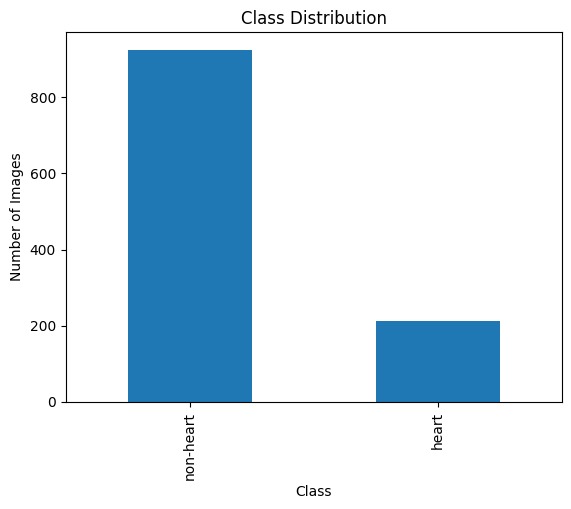

In [30]:
class_counts = pd.Series(y).map({0: "non-heart", 1: "heart"}).value_counts()

class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 908
Testing samples: 228


In [32]:
models = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(kernel="linear"))
    ])
}

In [33]:
results = []

for model_name, model in models.items():
    start_time = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    runtime = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary"
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Runtime (seconds)": runtime
    })

    print(f"\n{model_name} Classification Report")
    print(classification_report(y_test, y_pred))


KNN Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       186
           1       1.00      1.00      1.00        42

    accuracy                           1.00       228
   macro avg       1.00      1.00      1.00       228
weighted avg       1.00      1.00      1.00       228


SVM Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       186
           1       1.00      1.00      1.00        42

    accuracy                           1.00       228
   macro avg       1.00      1.00      1.00       228
weighted avg       1.00      1.00      1.00       228



In [34]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,Runtime (seconds)
0,KNN,1.0,1.0,1.0,1.0,0.121672
1,SVM,1.0,1.0,1.0,1.0,0.170273


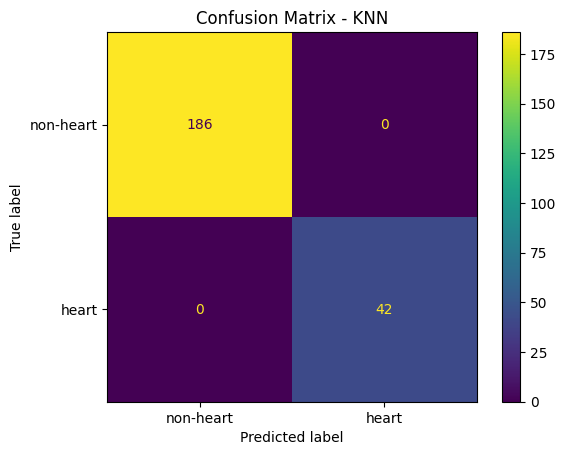

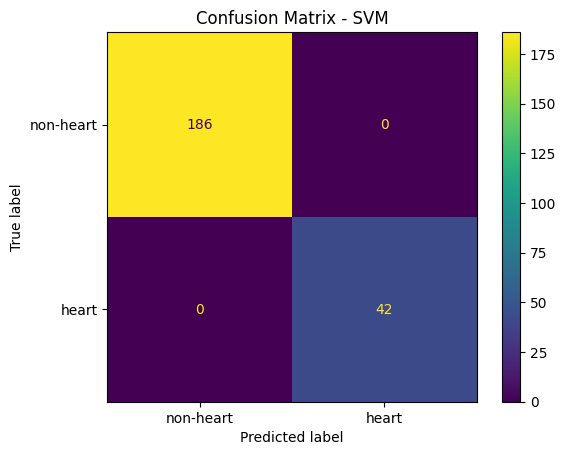

In [35]:
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non-heart", "heart"])
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# Experiment 2
***
*Using Neural Networks to distinguish between open and closed mitral valve cardiac images*
***

This experiment is significantly more challenging than the first experiment, as the model must differentiate between subtle structural differences within the same anatomical region. Both classes represent cardiac ultrasound images, meaning that visual patterns are highly similar and the classifier must rely on fine grained spatial features.

A convolutional neural network (CNN) was used due to its ability to learn hierarchical spatial representations directly from image data. This is essential for capturing subtle variations in valve structure that cannot be effectively represented using flattened feature vectors.

The model achieved strong overall performance, with accuracy ranging from 0.90 to 1.00 and F1-scores consistently above 0.92 across all folds. AUC-ROC values were also high (≥0.96), indicating good class separability. However, performance was not perfectly consistent, with some folds (e.g. Fold 1 and Fold 3) showing lower recall values.

Analysis of confusion matrices show that errors are primarily false negatives, where the model fails to correctly identify one of the valve states. This is reflected in the high precision (often 1.00) but lower recall in some folds, suggesting that the model is conservative in its predictions and occasionally misses positive cases.

The variation in performance across folds highlights the impact of the small dataset size. While some folds achieve perfect classification, others show reduced performance, indicating sensitivity to the specific training data. This suggests that the learned features do not generalise perfectly across all subsets of the data.

Overall, the CNN is more appropriate for this task than traditional classifiers, as it uses spatial information critical for distinguishing subtle anatomical differences. However, the results also demonstrate that this remains a challenging fine-grained medical imaging problem, where limited data and high visual similarity between classes impact model performance.

In [36]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [37]:
base_path = "/content/drive/MyDrive/data_cw"

def load_image_arrays(folder, label, image_size=(64, 64)):
    images = []
    labels = []

    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, image_size)
        images.append(img)
        labels.append(label)

    return images, labels

heart_open_path = os.path.join(base_path, "heart", "open")
heart_closed_path = os.path.join(base_path, "heart", "closed")

open_images, open_labels = load_image_arrays(heart_open_path, 1)
closed_images, closed_labels = load_image_arrays(heart_closed_path, 0)

X = np.array(open_images + closed_images, dtype=np.float32)
y = np.array(open_labels + closed_labels)

print("Total heart images:", len(X))
print("Open images:", np.sum(y == 1))
print("Closed images:", np.sum(y == 0))
print("Image shape before reshape:", X.shape)

Total heart images: 211
Open images: 136
Closed images: 75
Image shape before reshape: (211, 64, 64)


In [ ]:
X = X / 255.0

X = X.reshape(-1, 64, 64, 1)

print("Image shape for CNN:", X.shape)

Image shape for CNN: (211, 64, 64, 1)


In [39]:
def build_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [40]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
confusion_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n--- Fold {fold} ---")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = build_cnn()

    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=16,
        verbose=0
    )

    runtime = time.time() - start_time

    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    confusion_matrices.append(cm)

    fold_results.append({
        "Fold": fold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "AUC-ROC": auc,
        "Runtime (seconds)": runtime
    })

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("AUC-ROC:", auc)
    print("Runtime:", runtime)
    print("Confusion Matrix:\n", cm)


--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.9069767441860465
Precision: 1.0
Recall: 0.8571428571428571
F1-score: 0.9230769230769231
AUC-ROC: 0.9880952380952381
Runtime: 12.936655282974243
Confusion Matrix:
 [[15  0]
 [ 4 24]]

--- Fold 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
AUC-ROC: 1.0
Runtime: 12.525285482406616
Confusion Matrix:
 [[15  0]
 [ 0 27]]

--- Fold 3 ---


...

Accuracy: 0.9047619047619048
Precision: 0.96
Recall: 0.8888888888888888
F1-score: 0.9230769230769231
AUC-ROC: 0.9629629629629629
Runtime: 13.531953573226929
Confusion Matrix:
 [[14  1]
 [ 3 24]]

--- Fold 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.9285714285714286
Precision: 0.9285714285714286
Recall: 0.9629629629629629
F1-score: 0.9454545454545454
AUC-ROC: 0.9604938271604938
Runtime: 13.401581764221191
Confusion Matrix:
 [[13  2]
 [ 1 26]]

--- Fold 5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.9761904761904762
Precision: 0.9642857142857143
Recall: 1.0
F1-score: 0.9818181818181818
AUC-ROC: 1.0
Runtime: 13.956294059753418
Confusion Matrix:
 [[14  1]
 [ 0 27]]


In [41]:
results_df = pd.DataFrame(fold_results)
results_df

,Fold,Accuracy,Precision,Recall,F1-score,AUC-ROC,Runtime (seconds)
0,1,0.906977,1.000000,0.857143,0.923077,0.988095,12.936655
1,2,1.000000,1.000000,1.000000,1.000000,1.000000,12.525285
2,3,0.904762,0.960000,0.888889,0.923077,0.962963,13.531954
3,4,0.928571,0.928571,0.962963,0.945455,0.960494,13.401582
4,5,0.976190,0.964286,1.000000,0.981818,1.000000,13.956294


In [42]:
average_results = pd.DataFrame([{
    "Average Accuracy": results_df["Accuracy"].mean(),
    "Average Precision": results_df["Precision"].mean(),
    "Average Recall": results_df["Recall"].mean(),
    "Average F1-score": results_df["F1-score"].mean(),
    "Average AUC-ROC": results_df["AUC-ROC"].mean(),
    "Average Runtime (seconds)": results_df["Runtime (seconds)"].mean()
}])

average_results

,Average Accuracy,Average Precision,Average Recall,Average F1-score,Average AUC-ROC,Average Runtime (seconds)
0,0.9433,0.970571,0.941799,0.954685,0.98231,13.270354


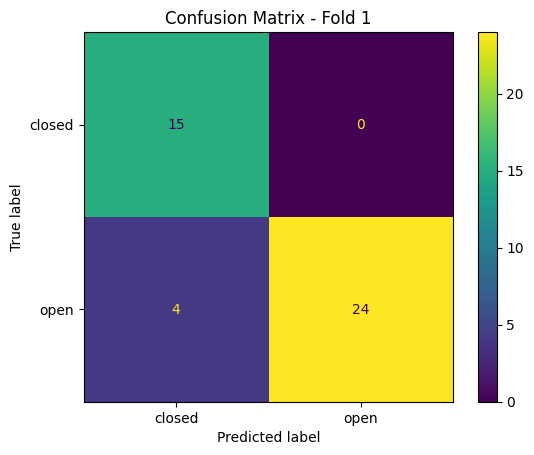

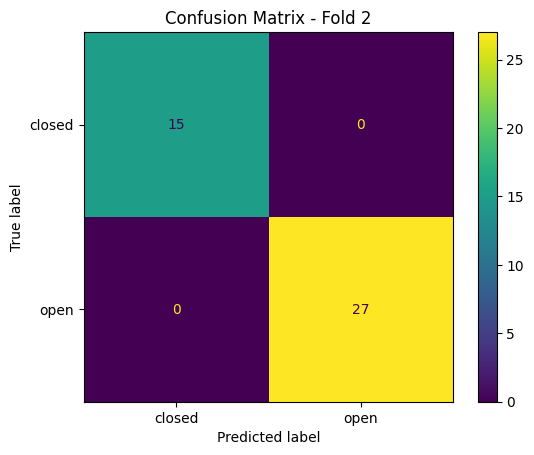

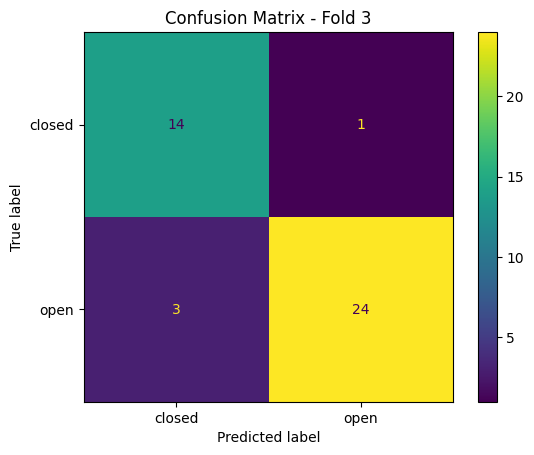

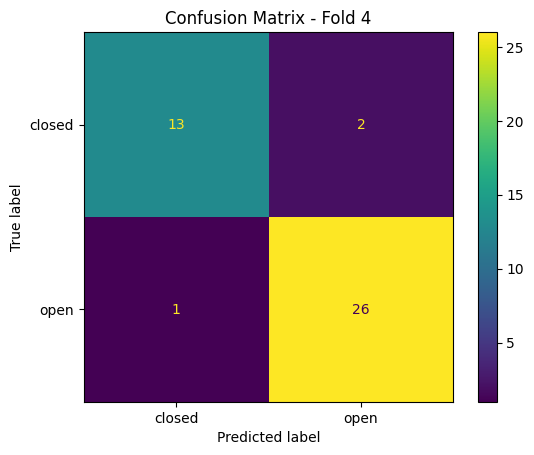

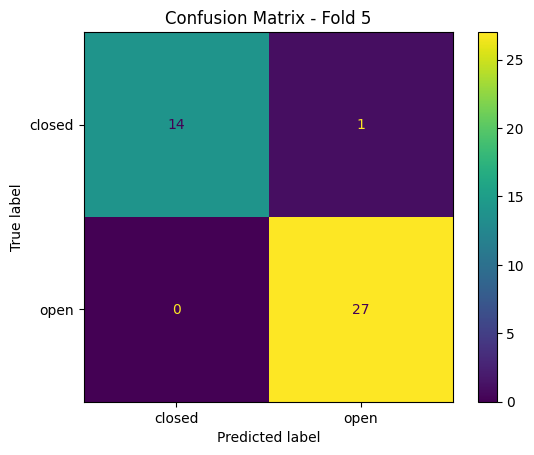

In [43]:
for i, cm in enumerate(confusion_matrices, start=1):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["closed", "open"])
    disp.plot()
    plt.title(f"Confusion Matrix - Fold {i}")
    plt.show()

# Experiment 3
***
Transfer learning and data augmentation for mitral valve state classification
***

This experiment extends the previous approach by incorporating data augmentation and transfer learning to improve model generalisation. A MobileNetV2 architecture was selected due to its use of depthwise separable convolutions, which provide an efficient yet powerful feature extraction mechanism. This makes it particularly suitable for small medical imaging datasets, where training a deep model from scratch would likely lead to overfitting.

The convolutional base was frozen to retain low- and mid-level visual features learned from ImageNet, such as edges, textures and shapes. These features remain relevant for ultrasound images despite the domain shift. A custom classification head was added to adapt the model to the binary classification task. Data augmentation was applied exclusively to the training data in each fold, increasing variability while preserving the integrity of the validation set.

The model achieved strong performance across folds, with accuracy ranging from 0.86 to 1.00 and F1-scores reaching 1.00 in multiple cases. Compared to Experiment 2, this represents a clear improvement in both peak performance and overall robustness. This suggests that transfer learning enables the model to leverage more generalisable feature representations, while augmentation reduces overfitting by exposing the model to a wider range of training examples.

However, performance was not fully consistent across all folds. In particular, Fold 3 showed a noticeable drop in performance (accuracy = 0.86, F1 = 0.89), with both false positives and false negatives observed. This indicates that certain samples remain difficult to classify, likely due to subtle anatomical differences and noise inherent in ultrasound imaging. The persistence of these errors suggests that even advanced models struggle to fully capture fine-grained distinctions in limited datasets.

The variability across folds highlights that, although generalisation has improved, the model remains sensitive to the specific training data. This reflects the high variance typically associated with small datasets and complex classification boundaries.

From a computational perspective, the runtime increased substantially compared to Experiment 2, due to the added complexity of transfer learning and augmentation. This introduces a trade-off between predictive performance and efficiency, which is an important consideration in real-world clinical deployment.

From an explainability perspective, techniques such as Grad-CAM could be applied to visualise which regions of the image contribute most to the model’s predictions. If the model focuses on the mitral valve region, this would provide evidence that it is learning clinically meaningful features. Conversely, attention to irrelevant regions would indicate that the model may be relying on spurious correlations, limiting its reliability.

Overall, this experiment demonstrates that transfer learning and data augmentation significantly improve performance and generalisation. However, the results also confirm that fine-grained medical image classification remains inherently challenging, particularly when limited data and subtle structural differences are involved.

In [44]:
import os
import cv2
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [45]:
base_path = "/content/drive/MyDrive/data_cw"

def load_image_arrays(folder, label, image_size=(96, 96)):
    images = []
    labels = []

    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, image_size)
        images.append(img)
        labels.append(label)

    return images, labels

heart_open_path = os.path.join(base_path, "heart", "open")
heart_closed_path = os.path.join(base_path, "heart", "closed")

open_images, open_labels = load_image_arrays(heart_open_path, 1)
closed_images, closed_labels = load_image_arrays(heart_closed_path, 0)

X = np.array(open_images + closed_images, dtype=np.float32)
y = np.array(open_labels + closed_labels)

print("Total heart images:", len(X))
print("Open images:", np.sum(y == 1))
print("Closed images:", np.sum(y == 0))
print("Image shape before processing:", X.shape)

Total heart images: 211
Open images: 136
Closed images: 75
Image shape before processing: (211, 96, 96)


In [ ]:
X = np.expand_dims(X, axis=-1)             
X = np.repeat(X, 3, axis=-1)                

print("Image shape for transfer learning:", X.shape)

Image shape for transfer learning: (211, 96, 96, 3)


In [47]:
class AugmentedSequence(Sequence):
    def __init__(self, X, y, datagen, batch_size=16, augment_factor=10, shuffle=True):
        self.X = X
        self.y = y
        self.datagen = datagen
        self.batch_size = batch_size
        self.augment_factor = augment_factor
        self.shuffle = shuffle

        self.indices = np.arange(len(self.X))
        self.total_samples = len(self.X) * self.augment_factor
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(self.total_samples / self.batch_size)

    def __getitem__(self, idx):
        batch_x = []
        batch_y = []

        for _ in range(self.batch_size):
            original_idx = np.random.choice(self.indices)
            img = self.X[original_idx]
            label = self.y[original_idx]

            img = img.reshape((1,) + img.shape)
            aug_iter = self.datagen.flow(img, batch_size=1, shuffle=False)
            aug_img = next(aug_iter)[0]

            batch_x.append(aug_img)
            batch_y.append(label)

        batch_x = np.array(batch_x, dtype=np.float32)
        batch_y = np.array(batch_y, dtype=np.float32)

        batch_x = preprocess_input(batch_x)

        return batch_x, batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [48]:
def build_transfer_model(input_shape=(96, 96, 3)):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Freeze pretrained layers
    for layer in base_model.layers:
        layer.trainable = False

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [49]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
confusion_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n--- Fold {fold} ---")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    train_sequence = AugmentedSequence(
        X_train, y_train,
        datagen=datagen,
        batch_size=16,
        augment_factor=10
    )

    
    X_test_preprocessed = preprocess_input(X_test.copy())

    model = build_transfer_model(input_shape=(96, 96, 3))

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    start_time = time.time()

    history = model.fit(
        train_sequence,
        validation_data=(X_test_preprocessed, y_test),
        epochs=10,
        verbose=0,
        callbacks=[early_stop]
    )

    runtime = time.time() - start_time

    y_prob = model.predict(X_test_preprocessed, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    confusion_matrices.append(cm)

    fold_results.append({
        "Fold": fold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "AUC-ROC": auc,
        "Runtime (seconds)": runtime
    })

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("AUC-ROC:", auc)
    print("Runtime:", runtime)
    print("Confusion Matrix:\n", cm)


--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
AUC-ROC: 1.0
Runtime: 97.34303545951843
Confusion Matrix:
 [[15  0]
 [ 0 28]]

--- Fold 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Accuracy: 0.9761904761904762
Precision: 0.9642857142857143
Recall: 1.0
F1-score: 0.9818181818181818
AUC-ROC: 1.0
Runtime: 114.55588912963867
Confusion Matrix:
 [[14  1]
 [ 0 27]]

--- Fold 3 ---


...

Accuracy: 0.8571428571428571
Precision: 0.8888888888888888
Recall: 0.8888888888888888
F1-score: 0.8888888888888888
AUC-ROC: 0.945679012345679
Runtime: 67.83473587036133
Confusion Matrix:
 [[12  3]
 [ 3 24]]

--- Fold 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Accuracy: 0.9523809523809523
Precision: 0.9310344827586207
Recall: 1.0
F1-score: 0.9642857142857143
AUC-ROC: 0.9679012345679012
Runtime: 69.21425914764404
Confusion Matrix:
 [[13  2]
 [ 0 27]]

--- Fold 5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
AUC-ROC: 1.0
Runtime: 165.83557796478271
Confusion Matrix:
 [[15  0]
 [ 0 27]]


In [51]:
results_df = pd.DataFrame(fold_results)
results_df

,Fold,Accuracy,Precision,Recall,F1-score,AUC-ROC,Runtime (seconds)
0,1,1.000000,1.000000,1.000000,1.000000,1.000000,97.343035
1,2,0.976190,0.964286,1.000000,0.981818,1.000000,114.555889
2,3,0.857143,0.888889,0.888889,0.888889,0.945679,67.834736
3,4,0.952381,0.931034,1.000000,0.964286,0.967901,69.214259
4,5,1.000000,1.000000,1.000000,1.000000,1.000000,165.835578


In [52]:
average_results = pd.DataFrame([{
    "Average Accuracy": results_df["Accuracy"].mean(),
    "Average Precision": results_df["Precision"].mean(),
    "Average Recall": results_df["Recall"].mean(),
    "Average F1-score": results_df["F1-score"].mean(),
    "Average AUC-ROC": results_df["AUC-ROC"].mean(),
    "Average Runtime (seconds)": results_df["Runtime (seconds)"].mean()
}])

average_results

,Average Accuracy,Average Precision,Average Recall,Average F1-score,Average AUC-ROC,Average Runtime (seconds)
0,0.957143,0.956842,0.977778,0.966999,0.982716,102.9567


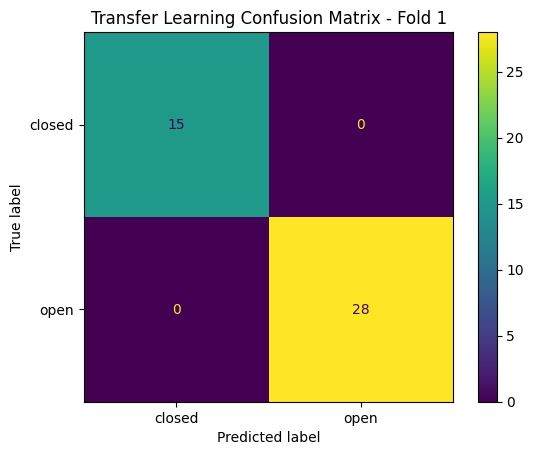

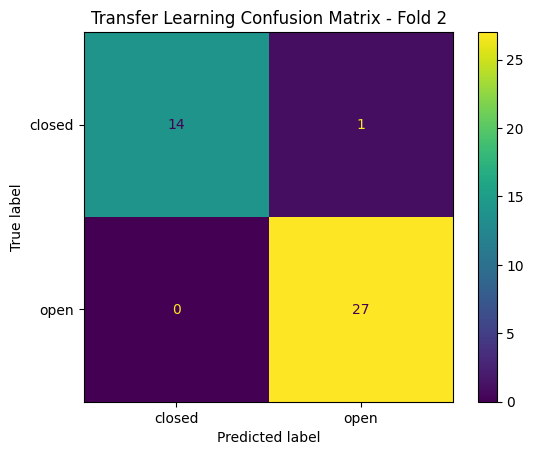

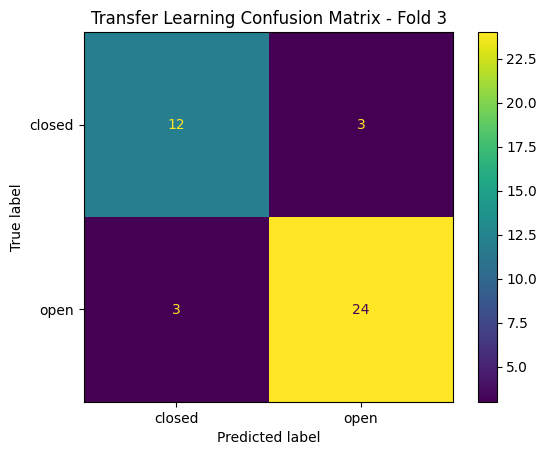

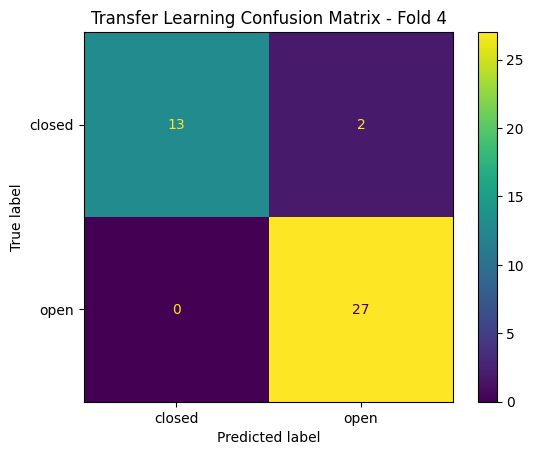

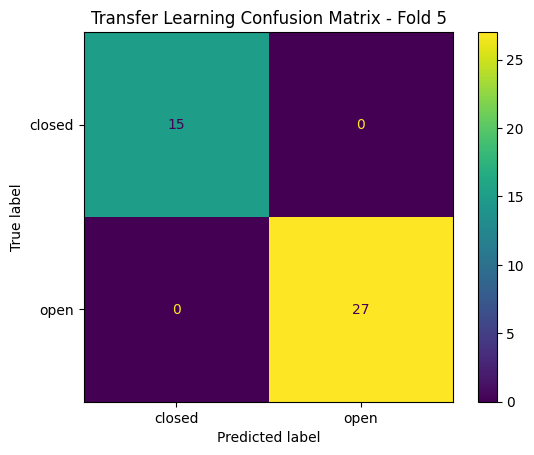

In [53]:
for i, cm in enumerate(confusion_matrices, start=1):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["closed", "open"])
    disp.plot()
    plt.title(f"Transfer Learning Confusion Matrix - Fold {i}")
    plt.show()

## Conclusion

This study demonstrates a clear progression in model capability across the three experiments. While traditional machine learning models were sufficient for distinguishing between anatomically distinct classes in Experiment 1, they were not suitable for fine-grain classification tasks. The introduction of a CNN in Experiment 2 improved performance by capturing spatial features, although results varied due to the limited dataset.

In Experiment 3, transfer learning and data augmentation further improved performance and generalisation, highlighting the importance of leveraging pre-trained models in small data scenarios. However, variability across folds and remaining classification errors indicate that the task remains inherently challenging.

Finally, the results emphasise that model complexity, data representation, and evaluation strategy are critical factors in medical image classification, particularly when dealing with subtle structural differences and limited data.

Word Count

In [2]:
import io
from nbformat import current

filepath = 'CMM536_Submission.ipynb' 

with io.open(filepath, 'r', encoding='utf-8') as f:
    nb = current.read(f, 'ipynb')

word_count = 0
for cell in nb.worksheets[0].cells:
    if cell.cell_type == "markdown":
        word_count += len(cell['source'].replace('#', '').lstrip().split(' '))
print("Total word count: ", word_count)

Total word count:  1075


Generative AI Statement

Generative AI (ChatGPT) was used to assist with code debugging and improving the structure of the notebook. 

All AI-generated suggestions were critically evaluated and modified where necessary. The final code, analysis, and written explanations reflect my own understanding of machine learning concepts, experimental design, and result interpretation.